In [1]:
# Install modules (if not already done)
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install openpyxl

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


In [1]:
# Import modules
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Define filename and path
filename = os.path.join('data', 'XYZ_Corp_orders_sheet.xlsx')
print(filename)

# Read the Excel file
df = pd.read_excel(filename)

data/XYZ_Corp_orders_sheet.xlsx


In [5]:
# Display the top 3 rows
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [7]:
# Display the last 3 rows
df.tail(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [8]:
# Show the total number of rows and columns
df.shape

(9994, 21)

In [7]:
# Get dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [9]:
# Drop columns we are not interested in
df.drop(columns=['Row ID', 'Order ID', 'Customer ID'], inplace=True)

In [10]:
# Check the dataframe
df.head(3)

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


# Handle missing values

In [11]:
# Check for missing values
df.isna().sum()

Order Date       0
Ship Date        0
Ship Mode        0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Handle duplicates

In [12]:
# Find duplicates (By default keep='first')
df[df.duplicated()]

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3406,2014-04-23,2014-04-27,Standard Class,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


In [13]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [14]:
# Re-check for duplicate records
df[df.duplicated()]

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [15]:
# Round the 'Amount' column to 2 decimal places
df['Sales'] = df['Sales'].round(2)
df['Profit'] = df['Profit'].round(2)

# Display the top 5 rows
df.head(5)

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


# Visualize Data

In [16]:
# Get count of unique values for each category
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

In [17]:
# SQL Equivalent: SELECT Category, SUM(Sales) AS Sales, SUM(Profit) AS Profit FROM df GROUP BY Category

# Get sum for each category
df.groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,741718.36,18463.16
Office Supplies,719046.90,122490.00
Technology,836154.02,145455.44


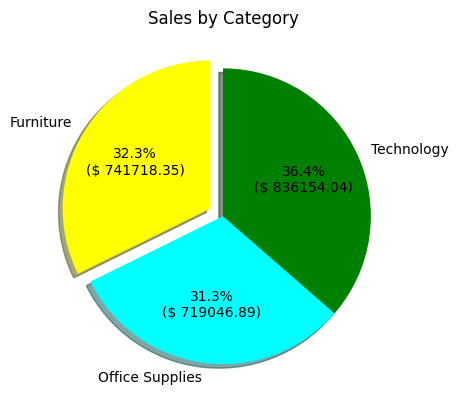

In [20]:
# Pie Plot

# Group by 'Category' and get the sum for each category
data = df.groupby('Category')['Sales'].sum()
labels = df['Category'].unique()
colors = ['yellow','cyan','green']

# Creating autocpt arguments
def format_value(pct, amounts):
        amount = pct / 100. * np.sum(amounts)
        return "{:.1f}%\n($ {:.2f})".format(pct, amount)

# Creating the figure and axis
fig, ax = plt.subplots()

ax.pie(data, labels=labels,
        colors=colors, # Define custom colors
        startangle=90, # Define starting angle
        shadow=True, # Display shadow
        explode=(0.1,0,0),
        autopct=lambda pct: format_value(pct, data))

plt.title('Sales by Category')

# Display the chart
plt.show()

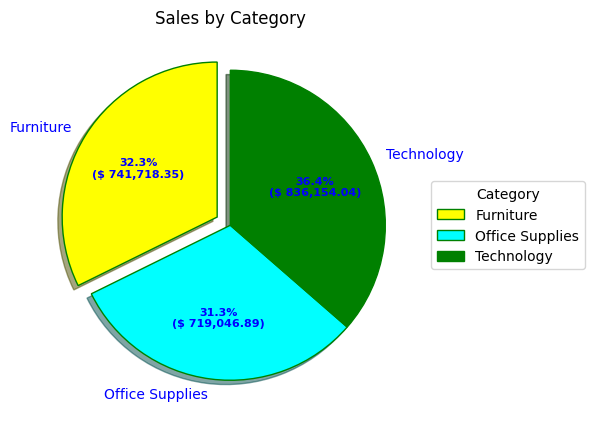

In [25]:
# Pie Plot: Using subplot

# Group by 'Category' and get the sum for each category
data = df.groupby('Category')['Sales'].sum()
labels = df['Category'].unique()
colors = ['yellow','cyan','green']

# Creating autocpt arguments
def format_value(pct, amounts):
        amount = pct / 100. * np.sum(amounts)
        return "{:.1f}%\n($ {:,.2f})".format(pct, amount)

# Wedge properties
wp = {'linewidth': 1, 'edgecolor': "green"}

# Creating plot
fig, ax = plt.subplots(figsize=(5, 7))
wedges, texts, autotexts = ax.pie(data,
                                autopct=lambda pct: format_value(pct, data),
                                explode=(0.1,0,0),
                                labels=labels,
                                shadow=True,
                                colors=colors,
                                startangle=90,
                                wedgeprops=wp,
                                textprops=dict(color="blue"))

# Adding legend
ax.legend(wedges,
          labels,
          title="Category",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Sales by Category")

# show plot
plt.show()

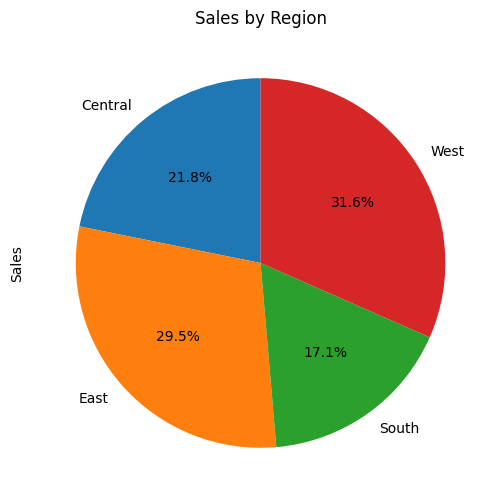

In [21]:
# Pie Chart: Sales by Region
plt.figure(figsize=(8, 6))

# Total sales per region
df_region_sales = df.groupby('Region')['Sales'].sum()

# Plot the data (pandas)
df_region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)

# Title
plt.title('Sales by Region')

# Display the plot
plt.show()

Category
Furniture          741718.36
Office Supplies    719046.90
Technology         836154.02
Name: Sales, dtype: float64


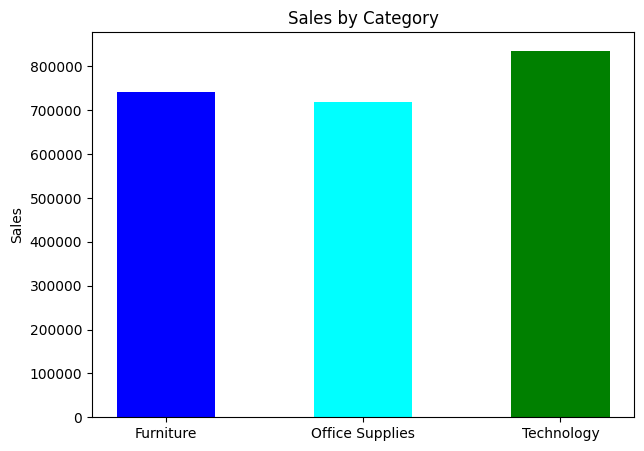

In [22]:
# Bar Plot (column)

# Total sales per category
values = df.groupby('Category')['Sales'].sum()
print(values)

labels = df['Category'].unique()
colors = ['blue', 'cyan', 'green']

# Wedge properties
wp = {'linewidth': 1, 'edgecolor': "green"}

# Creating plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x=labels,
       height=values,
       color=colors,
       width=0.5)

ax.set_title("Sales by Category")
ax.set_ylabel('Sales')

# show plot
plt.show()

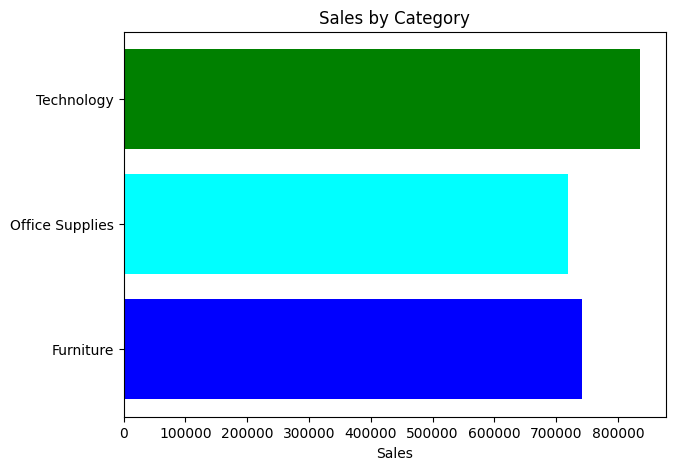

In [29]:
# Bar Plot
values = df.groupby('Category')['Sales'].sum()

labels = df['Category'].unique()
colors = ['blue','cyan','green']

# Creating plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(y=labels,
        width=values,
        color=colors)

ax.set_title('Sales by Category')
ax.set_xlabel('Sales')

# show plot
plt.show()

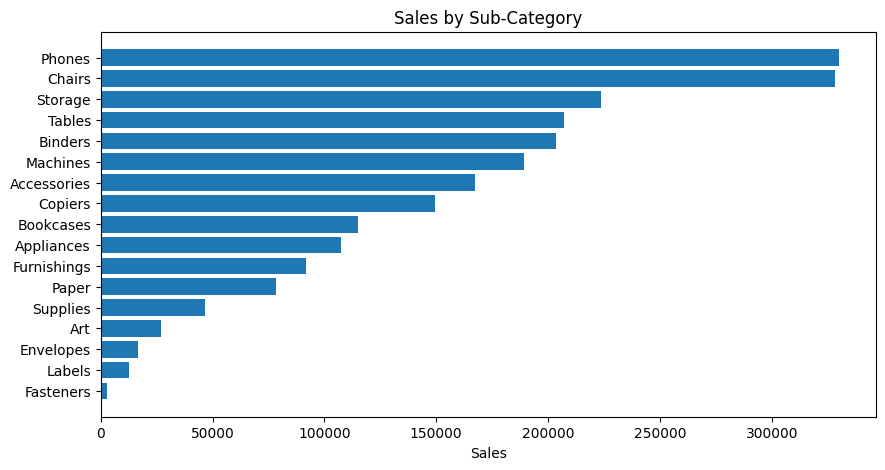

In [31]:
# Bar Plot by Sub category

# Group on Sub categories and get the total for each category
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values()

# Create separate columns for Sub category and Sales
df_result = sales_by_subcategory.reset_index()

sales = df_result['Sales']
labels = df_result['Sub-Category']
# colors = ['blue','cyan','green']

# Creating plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y=labels,
        width=sales,
        # color=colors
        )

ax.set_title('Sales by Sub-Category')
ax.set_xlabel('Sales')

# show plot
plt.show()

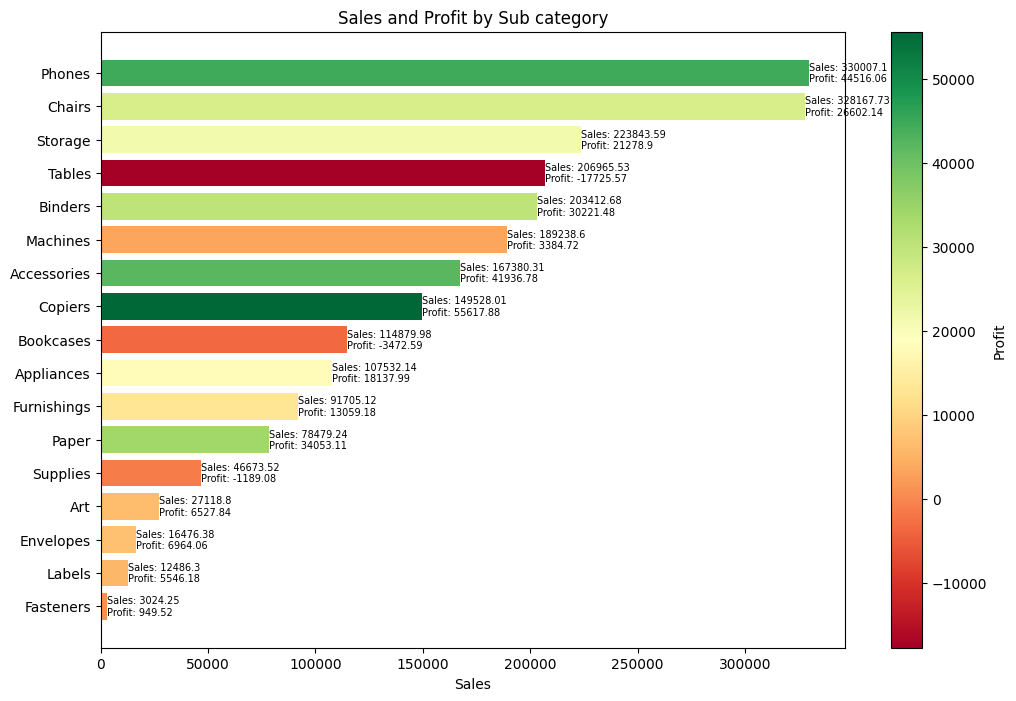

In [32]:
# Bar Plot: Sales and Profit by Sub category

# Group on Sub categories and get the total Sales and Profit for each category
grouped_by_subcategory = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()

# Sort by Sales in ascending order
sorted_sales = grouped_by_subcategory.sort_values(by='Sales', ascending=True)

# Extract the sorted order for Sub Category
sales_by_subcategory_index = sorted_sales.index

# Reindex the original grouped DataFrame to apply the same order to Profit
sorted_sales_profit = grouped_by_subcategory.loc[sales_by_subcategory_index]
# print(sorted_sales_profit)

# Create separate columns for Sub category, Sales and Profit
df_sorted_sales_profit = sorted_sales.reset_index()
# print(df_sorted_sales_profit)

sales = df_sorted_sales_profit['Sales'].round(2)
profit = df_sorted_sales_profit['Profit'].round(2)
labels = df_sorted_sales_profit['Sub-Category']

# Normalize profit values for colormap
norm = plt.Normalize(profit.min(), profit.max())

# Create a colormap
cmap = plt.cm.RdYlGn

# Creating plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(y=labels,
               width=sales,
               color=cmap(norm(profit))
               )

# Create a ScalarMappable and set the color map
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add a color bar
cbar = fig.colorbar(sm, ax=ax, label='Profit')

# Add annotations
for bar, sale, prof in zip(bars, sales, profit):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'Sales: {sale}\nProfit: {prof}', va='center', ha='left',
             color='black', fontsize=7)

ax.set_title('Sales and Profit by Sub category')
ax.set_xlabel('Sales')

# show plot
plt.show()

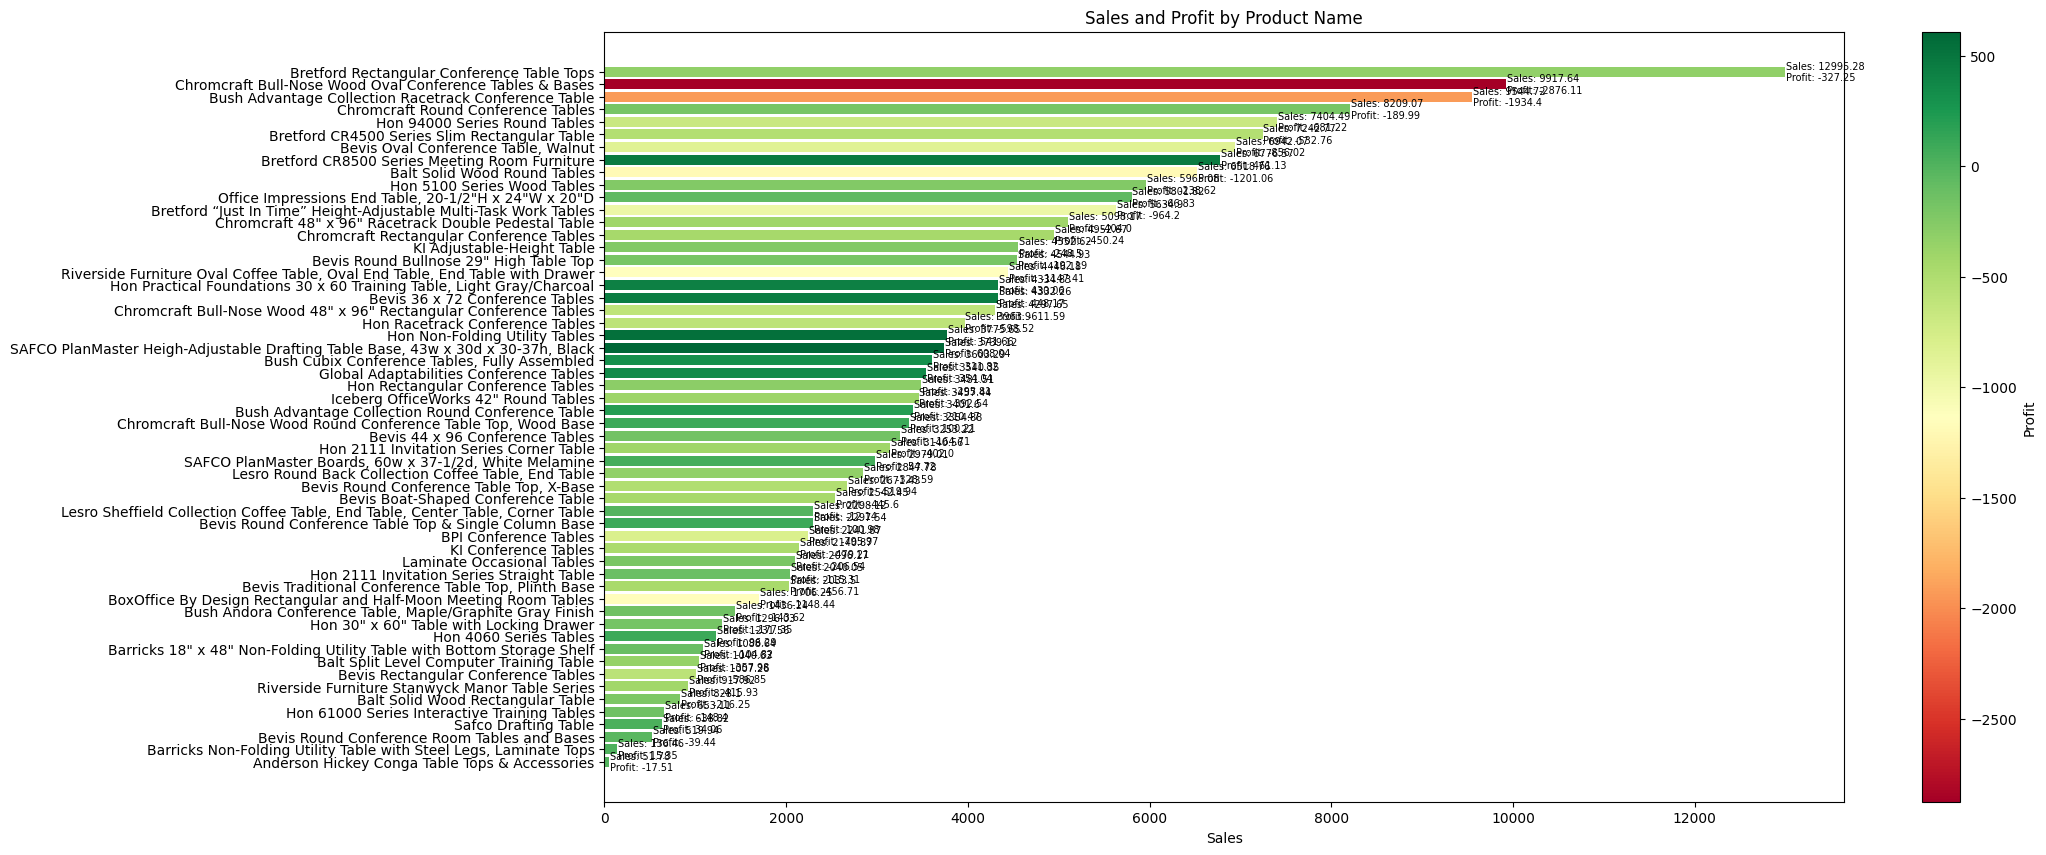

In [33]:
# Filter data on Sub-category "Tables"
# SQL: SELECT * FROM df WHERE Sub-Category = 'Tables'
df_subcategory_tables = df[df['Sub-Category'] == 'Tables']

# Bar Plot: Sales and Profit by Sub category

# Group on Product Name and get the total Sales and Profit for each Product
grouped_by_product_name = df_subcategory_tables.groupby('Product Name')[['Sales', 'Profit']].sum()

# Sort by Sales in ascending order
sorted_sales = grouped_by_product_name.sort_values(by='Sales', ascending=True)

# Extract the sorted order for Product Name
sales_by_product_name_index = sorted_sales.index

# Reindex the original grouped DataFrame to apply the same order to Profit
sorted_sales_profit = grouped_by_product_name.loc[sales_by_product_name_index]

# Create separate columns for Sub category, Sales and Profit
df_sorted_sales_profit = sorted_sales_profit.reset_index()

sales = df_sorted_sales_profit['Sales'].round(2)
profit = df_sorted_sales_profit['Profit'].round(2)
labels = df_sorted_sales_profit['Product Name']

# Normalize profit values for colormap
norm = plt.Normalize(profit.min(), profit.max())

# Create a colormap
cmap = plt.cm.RdYlGn

# Creating plot
fig, ax = plt.subplots(figsize=(20, 10))
bars = ax.barh(y=labels,
               width=sales,
               color=cmap(norm(profit))
               )

# Create a ScalarMappable and set the color map
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add a color bar
cbar = fig.colorbar(sm, ax=ax, label='Profit')

# Add annotations
for bar, sale, prof in zip(bars, sales, profit):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'Sales: {sale}\nProfit: {prof}', va='center', ha='left',
             color='black', fontsize=7)

ax.set_title('Sales and Profit by Product Name')
ax.set_xlabel('Sales')

# show plot
plt.show()

In [34]:
# Filter rows where 'Product Name' starts with 'Chromcraft' and ends with 'Tables & Bases' (& = bitwise AND operator)
df_filtered = df[df['Product Name'].str.startswith('Chromcraft') & df['Product Name'].str.endswith('Tables & Bases')]
df_filtered

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
721,2016-12-15,2016-12-19,Standard Class,Michael Paige,Corporate,United States,Detroit,Michigan,48205,Central,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,1652.94,3,0.0,231.41
2477,2017-09-04,2017-09-08,Second Class,Greg Maxwell,Corporate,United States,Los Angeles,California,90036,West,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,1322.35,3,0.2,-99.18
5320,2017-10-02,2017-10-05,First Class,Dean percer,Home Office,United States,Knoxville,Tennessee,37918,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,2314.12,7,0.4,-1002.78
9639,2015-01-28,2015-01-31,Second Class,Joseph Holt,Consumer,United States,Concord,North Carolina,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.64,13,0.4,-1862.31
9899,2014-03-28,2014-04-03,Standard Class,Mike Pelletier,Home Office,United States,Springfield,Ohio,45503,East,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,330.59,1,0.4,-143.25


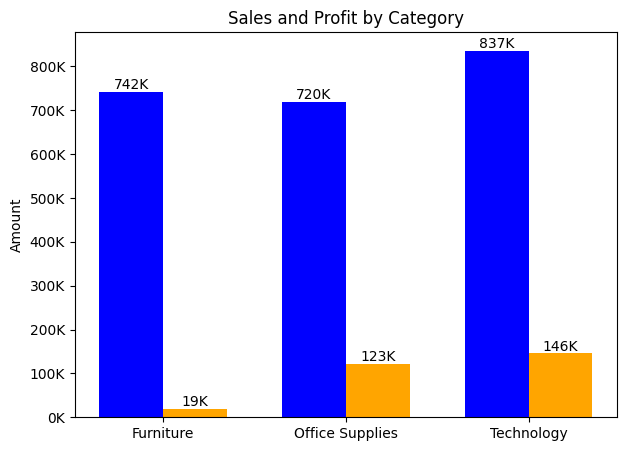

In [47]:
import math
import matplotlib.ticker as ticker

# Bar Plot (column) with Sales and Profit
sales = df.groupby('Category')['Sales'].sum()
profit = df.groupby('Category')['Profit'].sum()
labels = df['Category'].unique()

# Width of each bar
width = 0.35
ticks = np.arange(len(labels))

# Creating plot
fig, ax = plt.subplots(figsize=(7, 5))

# Sales plot
bar1 = ax.bar(x=ticks,
       height=sales,
       color=['blue'],
       width=width)

# Profit plot
bar2 = ax.bar(x=ticks + width,
       height=profit,
       color=['orange'],
       width=width)

# Add ticks and labels
ax.set_xticks(ticks + width/2)
ax.set_xticklabels(labels)

ax.set_title("Sales and Profit by Category")
ax.set_ylabel('Amount')

# Define a formatter function
def thousands_formatter(x, pos):
    return f'{math.ceil(x/1000)}K'

# Set the y-axis to use the formatter
ax.yaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))

# Displaying values on top of the bars
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 5, thousands_formatter(yval, 0), ha='center', va='bottom')

# Sales
add_labels(bar1)
# profit
add_labels(bar2)

# show plot
plt.show()

     Sub-Category Region   Sales
0       Bookcases  South  261.96
1          Chairs  South  731.94
2          Labels   West   14.62
3          Tables  South  957.58
4         Storage  South   22.37
...           ...    ...     ...
9989  Furnishings  South   25.25
9990  Furnishings   West   91.96
9991       Phones   West  258.58
9992        Paper   West   29.60
9993   Appliances   West  243.16

[9993 rows x 3 columns]
Region         Central       East     South       West
Sub-Category                                          
Accessories   33956.08   45033.38  27276.75   61114.10
Appliances    23581.98   34188.50  19525.34   30236.32
Art            5765.32    7485.77   4655.65    9212.06
Binders       56923.26   53498.06  37030.29   55961.07
Bookcases     24157.16   43819.33  10899.37   36004.12
Chairs        85230.67   95979.26  45176.44  101781.36
Copiers       37259.57   53219.46   9299.75   49749.23
Envelopes      4636.85    4375.88   3345.55    4118.10
Fasteners       778.02     81

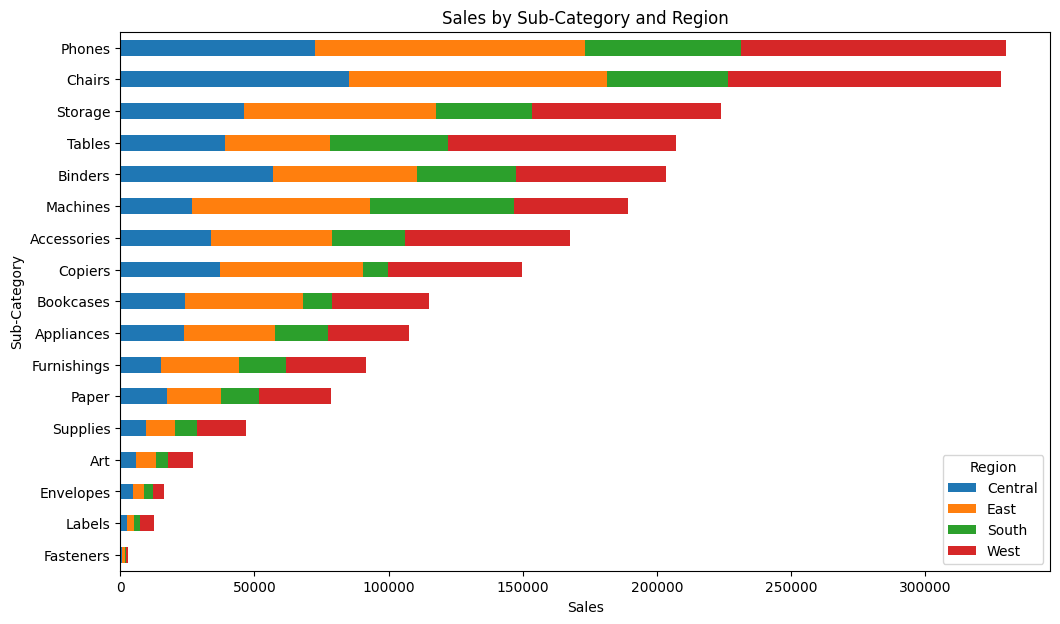

In [36]:
# Stacked bar Plot: Sales by Sub category and Region

# Select the necessary field from dataframe
df_sales_subcategory_region = df[['Sub-Category', 'Region', 'Sales']]
print(df_sales_subcategory_region)

# You need to reshape your DataFrame to have Sub-category as the index, Region as columns, and Sales as the values.
df_pivot = df_sales_subcategory_region.pivot_table(values='Sales', index='Sub-Category', columns='Region', aggfunc='sum', fill_value=0)
print(df_pivot)

# Calculate total sales for each sub-category
df_pivot['Total Sales'] = df_pivot.sum(axis=1)
# print(df_pivot)

# Sort by total sales
df_pivot = df_pivot.sort_values(by='Total Sales', ascending=True)

# Drop the 'Total Sales' column since it's no longer needed for plotting
df_pivot = df_pivot.drop(columns='Total Sales')

df_pivot.plot(figsize=(12, 7), kind='barh', stacked=True)

# Add labels and title
plt.ylabel('Sub-Category')
plt.xlabel('Sales')
plt.title('Sales by Sub-Category and Region')
plt.legend(title='Region')
plt.show()

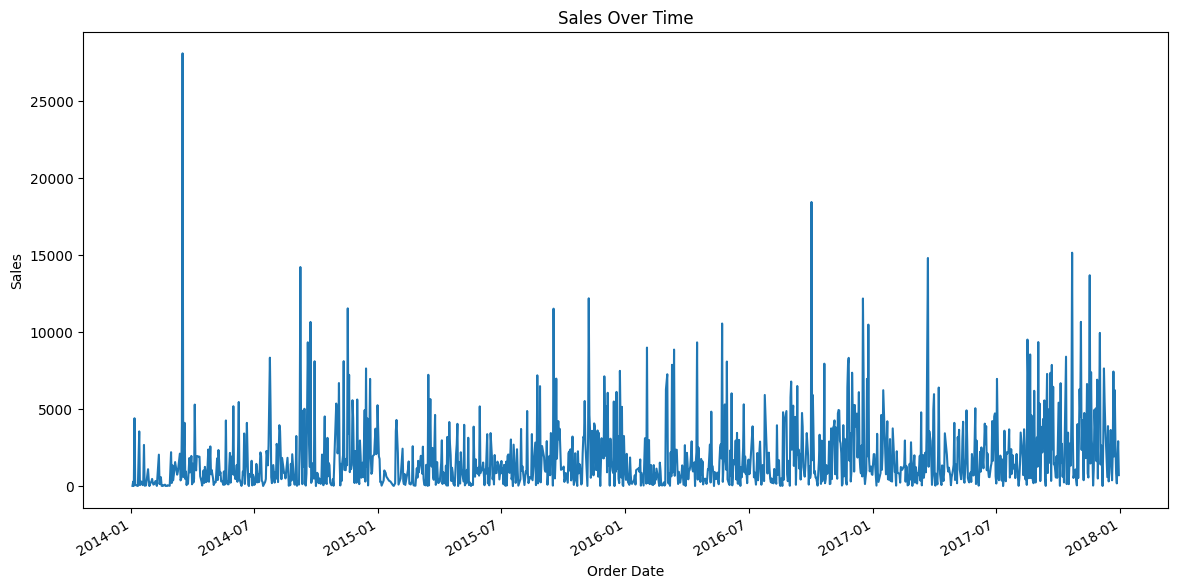

In [49]:
# Line Plot: Sales over Time
plt.figure(figsize=(14, 7))

df_sales_grouped_by_order_date = df.groupby('Order Date')['Sales'].sum()

# Plot
df_sales_grouped_by_order_date.plot()

plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.show()

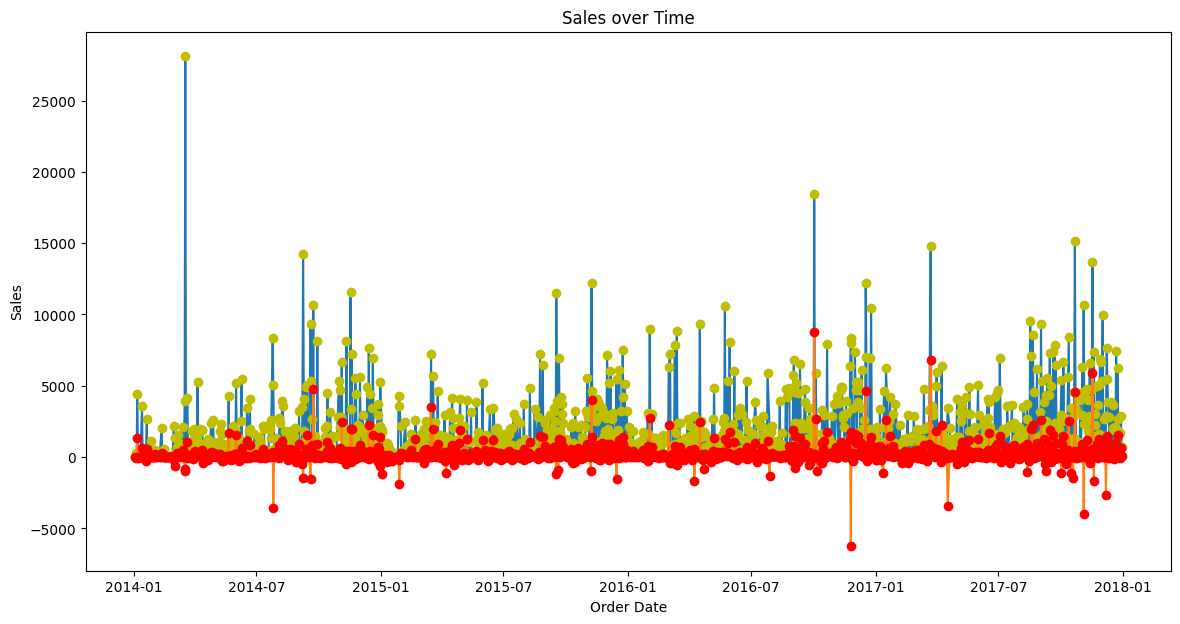

In [59]:
# Group on Sub categories and get the total Sales and Profit for each category
grouped_by_order_date = df.groupby('Order Date')[['Sales', 'Profit']].sum()

# Extract the sorted order for Sub Category
sales_by_order_date_index = grouped_by_order_date.index

# Reindex the original grouped DataFrame to apply the same order to Profit
sorted_profit = grouped_by_order_date.loc[sales_by_order_date_index]

# Create separate columns for Sub category, Sales and Profit
df_sorted_sales = grouped_by_order_date.reset_index()

sales = grouped_by_order_date['Sales'].round(2)
profit = sorted_profit['Profit'].round(2)
labels = df_sorted_sales['Order Date']

fig, ax = plt.subplots(figsize=(14, 7))

ax.set(xlabel='Order Date',
       ylabel='Sales',
       title='Sales over Time')

ax.plot(labels, sales,
        labels, sales, "oy",
        labels, profit,
        labels, profit, "or"
        )

plt.show()

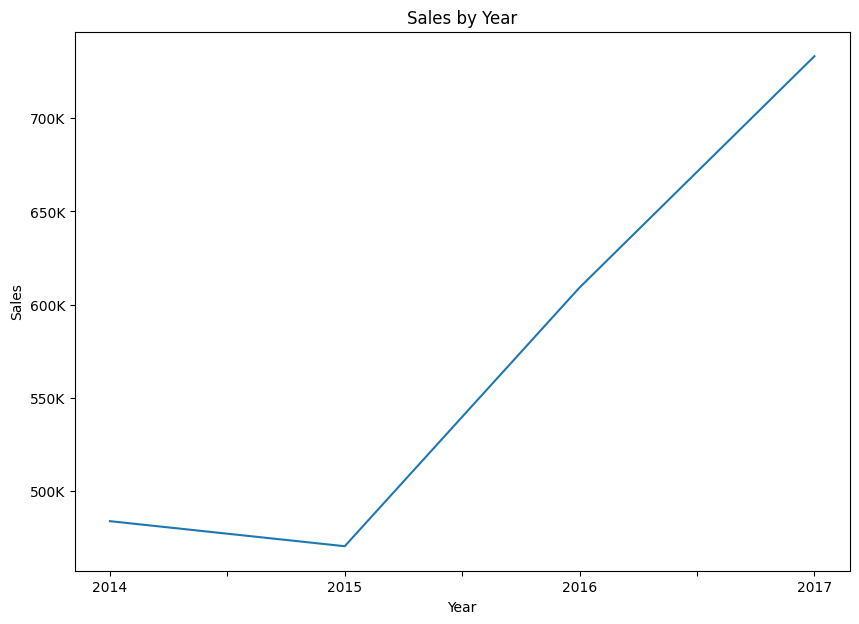

In [60]:
import math
import matplotlib.ticker as ticker

# Line Plot: Sales by Year
plt.figure(figsize=(10, 7))

# Convert 'Order Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract the year from 'Order Date'
df['Year'] = df['Order Date'].dt.year.astype(str)

# Group by 'Year' and sum the 'Sales'
df_sales_by_year = df.groupby('Year')['Sales'].sum()

# Plot
ax = df_sales_by_year.plot()

# Define a formatter function
def thousands_formatter(x, pos):
    return f'{math.ceil(x/1000)}K'

# Set the y-axis to use the formatter
ax.yaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))

plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

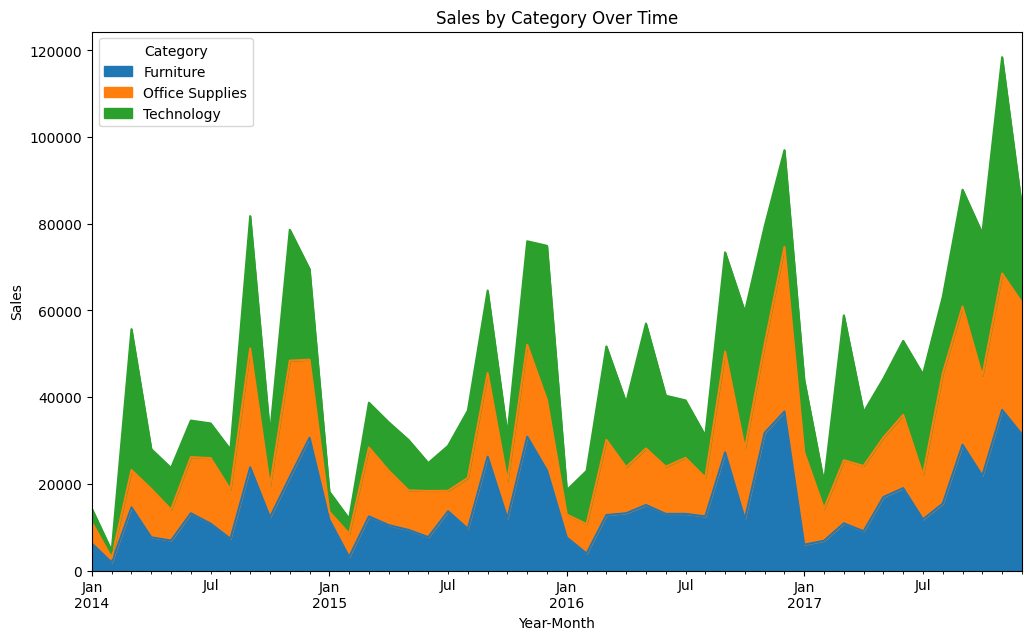

In [62]:
# Stacked Area Plot: Sales by Category Over Time

# Convert date to year/month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Create stack data
sales_by_category = df.groupby(['YearMonth', 'Category'])['Sales'].sum().unstack()

# Plot data
sales_by_category.plot(kind='area', stacked=True, figsize=(12, 7))

plt.title('Sales by Category Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Sales')
plt.show()

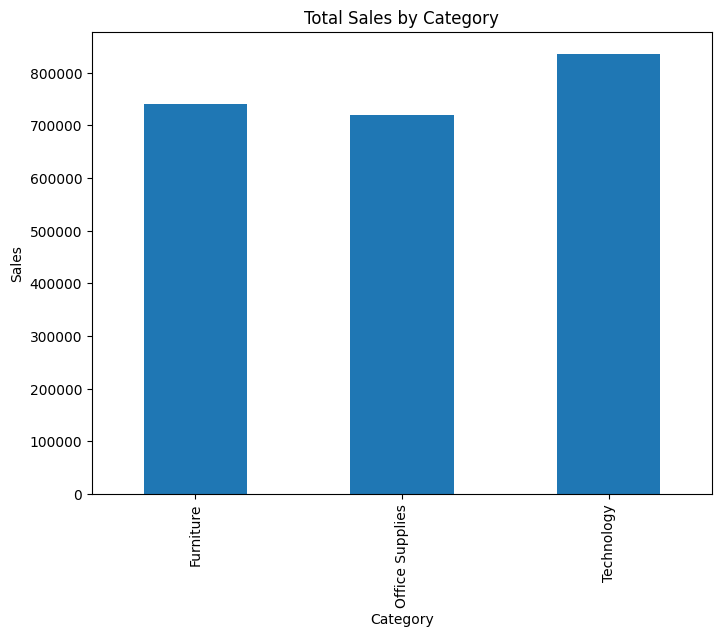

In [63]:
# Bar Plot: Total Sales by Category
plt.figure(figsize=(8, 6))

df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

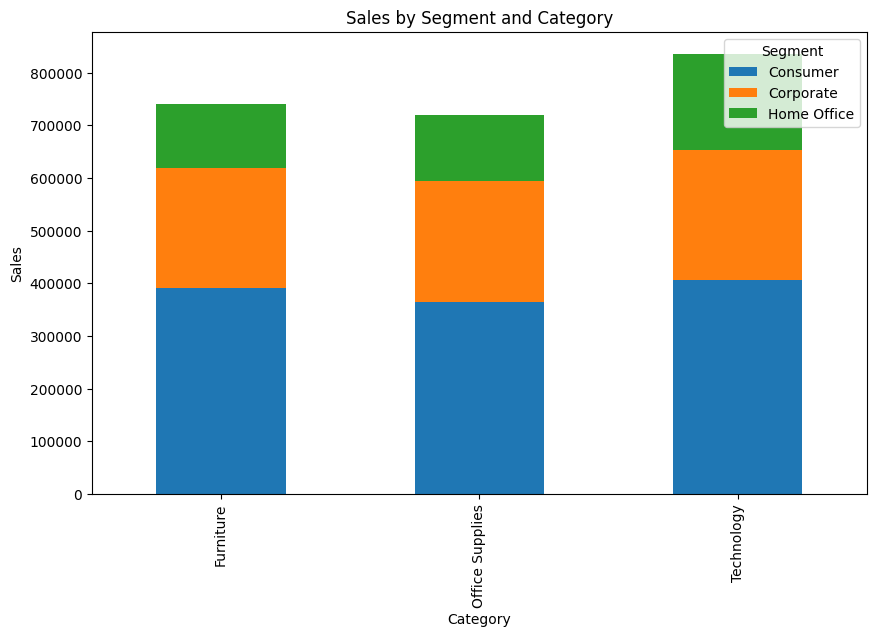

In [64]:
# Stacked Bar Plot: Sales by Segment and Category
sales_by_segment_category = df.groupby(['Category', 'Segment'])['Sales'].sum().unstack()
sales_by_segment_category.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Sales by Segment and Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

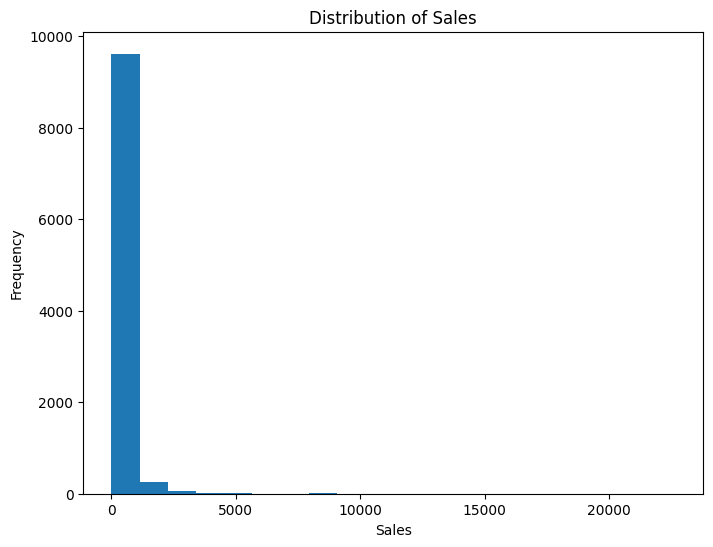

In [69]:
# Histogram: Distribution of Sales
plt.figure(figsize=(8, 6))

df['Sales'].plot(kind='hist', bins=20)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

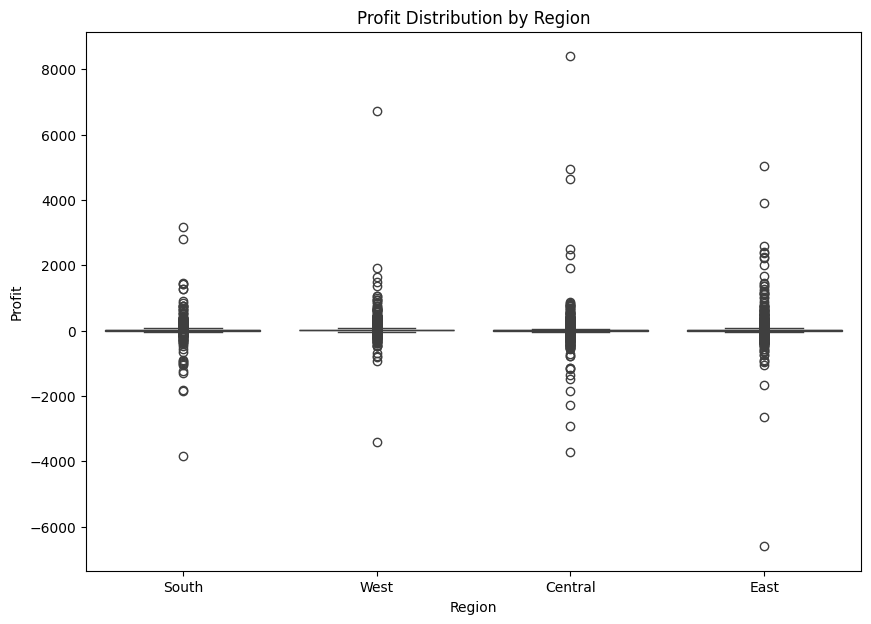

In [58]:
# Box Plot: Profit by Region
plt.figure(figsize=(10, 7))
sns.boxplot(x='Region', y='Profit', data=df)
plt.title('Profit Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

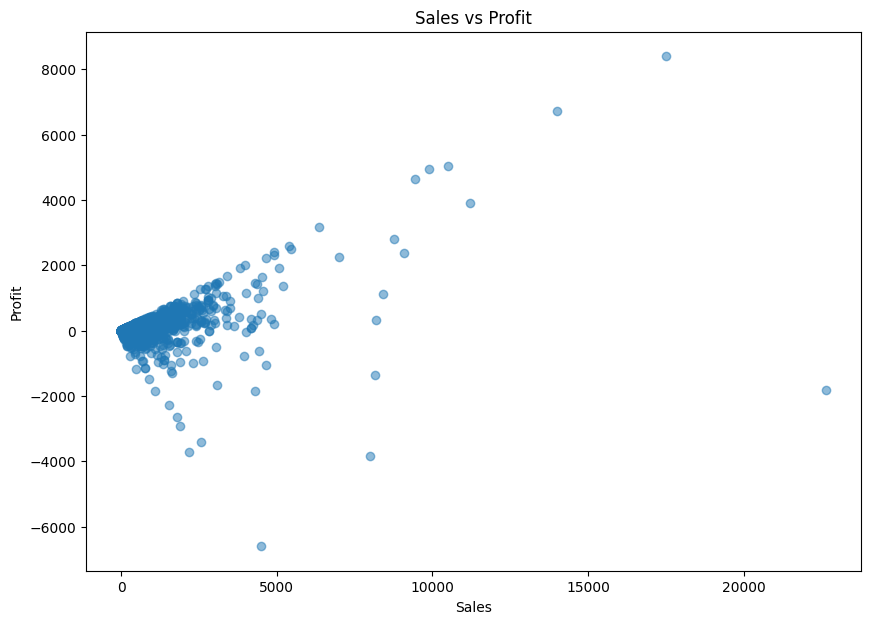

In [36]:
# Scatter Plot: Sales vs Profit
plt.figure(figsize=(10, 7))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

Int Columns
Index(['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

Correlation
       Sales  Quantity  Discount  Profit
0     261.96         2      0.00   41.91
1     731.94         3      0.00  219.58
2      14.62         2      0.00    6.87
3     957.58         5      0.45 -383.03
4      22.37         2      0.20    2.52
...      ...       ...       ...     ...
9989   25.25         3      0.20    4.10
9990   91.96         2      0.00   15.63
9991  258.58         2      0.20   19.39
9992   29.60         4      0.00   13.32
9993  243.16         2      0.00   72.95

[9993 rows x 4 columns]


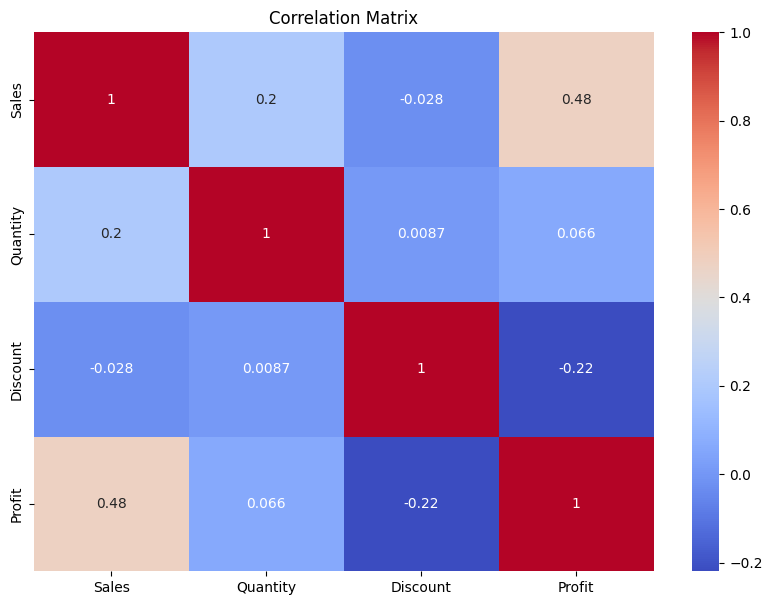

In [41]:
# Heatmap: Correlation Matrix
# Correlation interpretation:
# - 0.00 - 0.20 = Very weak correlation
# - 0.20 - 0.40 = Weak correlation
# - 0.40 - 0.60 = Moderate correlation
# - 0.60 - 0.80 = Strong correlation
# - 0.80 - 1.00 = Very Strong correlation

int_float_columns = df.select_dtypes(include=['int', 'float']).columns
print("Int Columns")
print(int_float_columns)

df_corr = df[int_float_columns].drop(columns=['Postal Code'])
print("\nCorrelation")
print(df_corr)

plt.figure(figsize=(10, 7))

# Seaborn library
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

<Figure size 1200x1000 with 0 Axes>

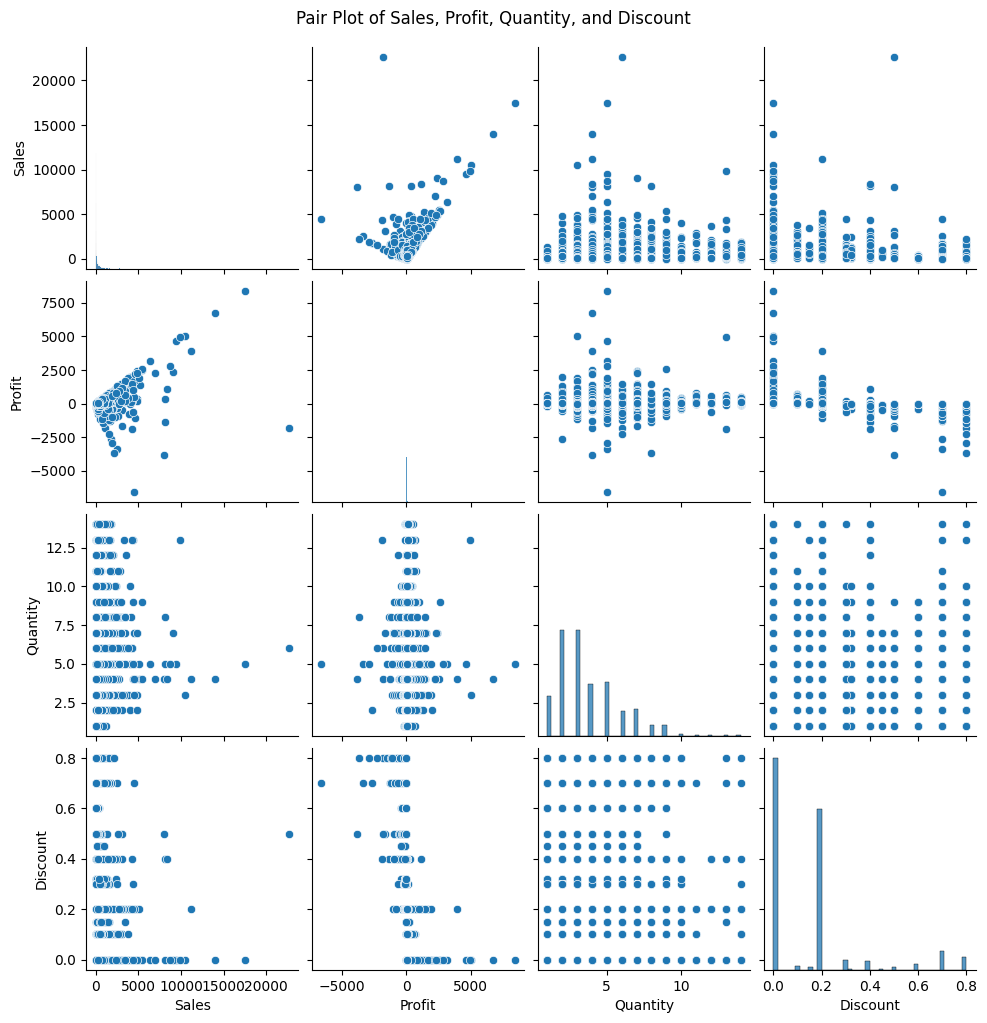

In [ ]:
# Pair Plot: Relationships between Variables
plt.figure(figsize=(12, 10))

sns.pairplot(df[['Sales', 'Profit', 'Quantity', 'Discount']])
plt.suptitle('Pair Plot of Sales, Profit, Quantity, and Discount', y=1.02)
plt.show()

# Animation

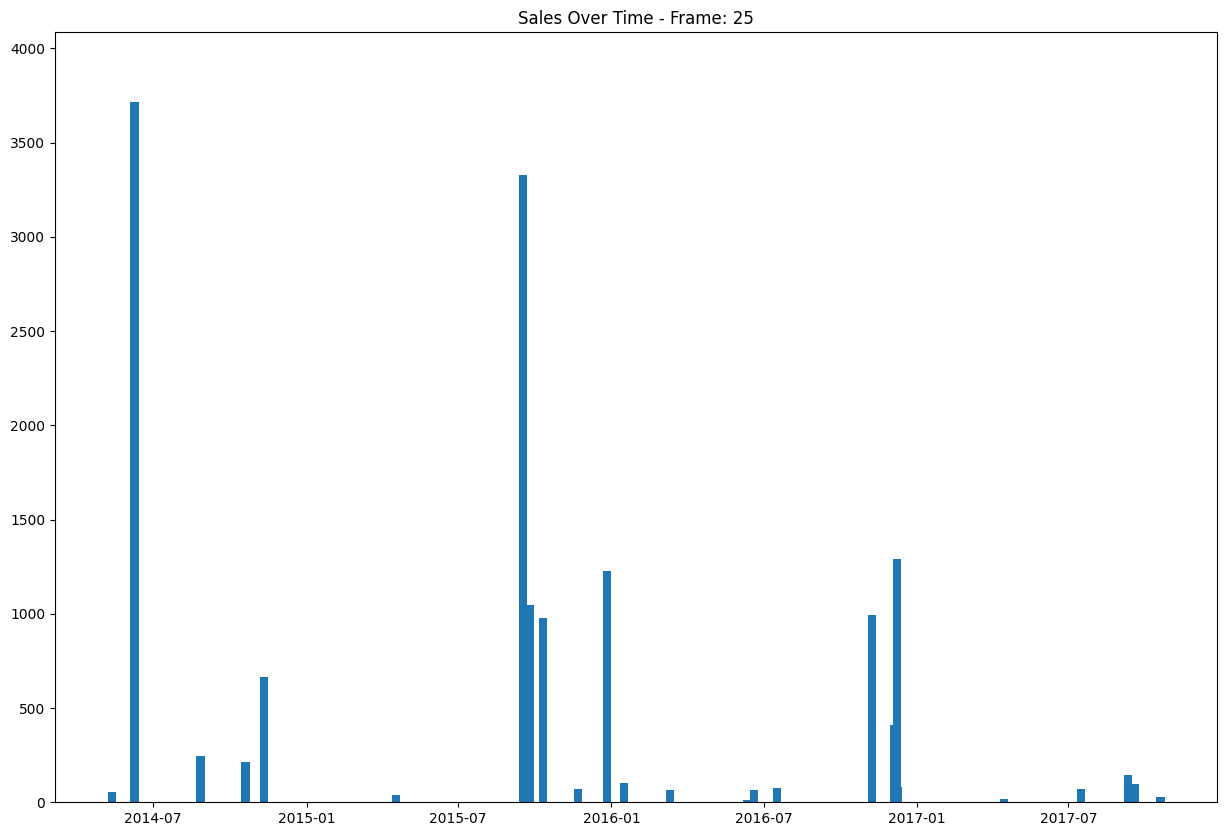

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Animate sales over time
df = df.iloc[:50,:].groupby('Order Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15,10))

# Create bar plot with only the first row
bar = ax.bar(df['Order Date'][0], df['Sales'][0])
ax.set_ylim(0, df['Sales'].max() * 1.1)

def update(frame):
    ax.clear()
    ax.bar(df['Order Date'][:frame+1], df['Sales'][:frame+1], width=10)
    ax.set_ylim(0, df['Sales'].max() * 1.1)
    ax.set_title(f"Sales Over Time - Frame: {frame+1}")

ani = animation.FuncAnimation(fig, update, frames=len(df), repeat=False)

# To save the animation
ani.save('sales_animation.mp4', writer='ffmpeg')

# To display the animation
plt.show()
